# Pose Analysis

In [1]:
import pandas as pd
import numpy as np
import torch
import json
import math
from tqdm import tqdm

In [2]:
all_examples = pd.read_csv("/Users/diyadinesh/egoexo4d_analysis/temporal_grounding.csv")
all_examples = all_examples[all_examples["split"]=="train"]
all_examples.head(), len(all_examples)

(                               take_uid               take_name  split  \
 0  80f65504-a37a-4c84-8a19-df3bba123326  georgiatech_covid_12_9  train   
 1  80f65504-a37a-4c84-8a19-df3bba123326  georgiatech_covid_12_9  train   
 2  80f65504-a37a-4c84-8a19-df3bba123326  georgiatech_covid_12_9  train   
 3  80f65504-a37a-4c84-8a19-df3bba123326  georgiatech_covid_12_9  train   
 4  80f65504-a37a-4c84-8a19-df3bba123326  georgiatech_covid_12_9  train   
 
                       scenario  segment_index  keystep_id  step_unique_id  \
 0  Covid-19 Rapid Antigen Test              0           6             821   
 1  Covid-19 Rapid Antigen Test              1          10             824   
 2  Covid-19 Rapid Antigen Test              2          52             863   
 3  Covid-19 Rapid Antigen Test              3          18             832   
 4  Covid-19 Rapid Antigen Test              4          16             830   
 
                                  keystep_name  \
 0                       Arr

In [3]:
print(len(all_examples["keystep_name"].unique()))

312


In [4]:
from ultralytics import YOLO
import cv2

model = YOLO("models/model.pt")
model.to("mps")

YOLO(
  (model): PoseModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03,

In [5]:
import torch

print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

MPS available: True
MPS built: True


In [6]:
#Find Best Camera for Analysis

confs = {"cam01":0.0, "cam02":0.0, "cam03":0.0, "cam04":0.0, "cam05":0.0}
total_count = {"cam01":0, "cam02":0, "cam03":0, "cam04":0, "cam05":0}

for take_uid in tqdm(all_examples["take_uid"].unique()):

    take_examples = all_examples[all_examples["take_uid"]==take_uid]
    if pd.isna(take_examples.iloc[0].exo_videos): continue
    exo_vids = take_examples.iloc[0].exo_videos.split("|")
    for exo_vid_index in range(len(exo_vids)):   
        
        vid_path = exo_vids[exo_vid_index]
    
        results = model.track(source = vid_path, stream = True, persist = True, verbose = False, device = "mps", vid_stride = 120, imgsz = 320)

        cur_cam = None
        if "cam01" in vid_path: cur_cam = "cam01"
        elif "cam02" in vid_path: cur_cam = "cam02"
        elif "cam03" in vid_path: cur_cam = "cam03"
        elif "cam04" in vid_path: cur_cam = "cam04"
        elif "cam05" in vid_path: cur_cam = "cam05"

        for i, result in enumerate(results):
    
            if result.keypoints is None: continue 
            xy = result.keypoints.xyn
            conf = result.keypoints.conf
    
            confs[cur_cam] += conf.sum().item()
            total_count[cur_cam] += conf.numel()
    #print(total_conf, count)
    #confidence_cam[exo_vid_index] = total_conf / count
#confidence_cam[exo_vid_index] /= count

    #for subj_ind, track_ind in enumerate(track_ids):
    #    cur_people[track_ind] = {"xy": xy[subj_ind], "conf": conf[subj_ind]}
for key in confs:
    confs[key] /= total_count[key]
        

100%|████████████████████████████████████████████████████████████████████████████████| 216/216 [12:32<00:00,  3.48s/it]


In [7]:
confs

{'cam01': 0.7104958614115635,
 'cam02': 0.6727321261022504,
 'cam03': 0.690940536032131,
 'cam04': 0.6875211130436271,
 'cam05': 0.6667758463469556}

In [8]:
best_camera = max(confs, key=confs.get)
best_camera, confs[best_camera]

('cam01', 0.7104958614115635)

In [9]:
all_pose = []

In [10]:
completed_takes = set(
    x["take_uid"] for x in all_pose
)

print("Already processed:", len(completed_takes))

Already processed: 0


In [11]:
joint_names = ["nose", "left_eye", "right_eye", "left_ear", "right_ear", "left_shoulder", "right_shoulder", "left_elbow", "right_elbow", "left_wrist", "right_wrist", "left_hip", "right_hip", "left_knee", "right_knee", "left_ankle", "right_ankle"]

In [12]:
exo_vid_index = 0

for take_uid in tqdm(all_examples["take_uid"].unique()):
    if take_uid in completed_takes:
        continue
        
    take_examples = all_examples[all_examples["take_uid"]==take_uid]
    if pd.isna(take_examples.iloc[0].exo_videos): continue
    exo_vids = take_examples.iloc[0].exo_videos.split("|")

    vid_path = exo_vids[exo_vid_index]

    if "cam01" not in vid_path: continue

    results = model.track(source = vid_path, stream = True, persist = True, verbose = False, device = "mps", vid_stride = 6, imgsz = 320)

    vid = cv2.VideoCapture(vid_path)
    fps = vid.get(cv2.CAP_PROP_FPS)
    vid.release()

    prev_people = {}

    for i, result in enumerate(results):
        time = i*6/fps

        if result.boxes.id is None:
            prev_people = {}
            continue

        xy = result.keypoints.xyn
        conf = result.keypoints.conf

        track_ids = result.boxes.id.int().cpu().tolist()

        cur_people = {}
        
        for subj_ind, track_ind in enumerate(track_ids):
            cur_people[track_ind] = {"xy": xy[subj_ind], "conf": conf[subj_ind]}

        motions = []

        for track_ind in cur_people:
            if track_ind not in prev_people: continue

            cur_xy = cur_people[track_ind]["xy"]
            #cur_conf = cur_people[track_ind]["conf"]

            prev_xy = prev_people[track_ind]["xy"]
            #prev_conf = prev_people[track_ind]["conf"]

            joint_diffs = torch.norm(cur_xy - prev_xy, dim = 1)#[]
            avg_motion = joint_diffs.mean().item()
            motions += [{"track_ind": track_ind, "motion": avg_motion, "joint_diffs": joint_diffs.cpu().tolist()}]
            """for joint_ind in range(17):
                diff = math.sqrt((cur_xy[joint_ind][0]-prev_xy[joint_ind][0])**2 + (cur_xy[joint_ind][1]-prev_xy[joint_ind][1])**2)
                joint_diffs += [diff]
            if len(joint_diffs)>0:
                avg_motion = np.mean(joint_diffs)
                motions += [{"track_ind": track_ind, "motion": avg_motion}]"""
        if len(motions) == 0:
            prev_people = cur_people
            continue
        most_active_person = max(motions, key=lambda x: x["motion"])
        temp = {"take_uid": take_uid, "video": vid_path, "frame": i*6, "time": time, "track_ind": most_active_person["track_ind"], "motion": most_active_person["motion"]}
        for joint_ind, joint in enumerate(joint_names):
            temp[joint] = most_active_person["joint_diffs"][joint_ind]
        all_pose += [temp]
        prev_people = cur_people

100%|████████████████████████████████████████████████████████████████████████████████| 216/216 [43:17<00:00, 12.02s/it]


In [13]:
pose_df = pd.DataFrame(all_pose)
pose_df.head()

,take_uid,video,frame,time,track_ind,motion,nose,left_eye,right_eye,left_ear,...,left_elbow,right_elbow,left_wrist,right_wrist,left_hip,right_hip,left_knee,right_knee,left_ankle,right_ankle
0,80f65504-a37a-4c84-8a19-df3bba123326,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,18,0.6,2607,0.040767,0.014872,0.013321,0.015173,0.008352,...,0.019402,0.034054,0.018369,0.028734,0.034900,0.047263,0.102587,0.106211,0.098596,0.100366
1,80f65504-a37a-4c84-8a19-df3bba123326,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,24,0.8,2607,0.026516,0.018552,0.018848,0.021348,0.019990,...,0.006722,0.023612,0.042325,0.015409,0.013835,0.030279,0.033447,0.045208,0.040155,0.047126
2,80f65504-a37a-4c84-8a19-df3bba123326,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,30,1.0,2607,0.031439,0.009790,0.009422,0.010183,0.009529,...,0.006737,0.032696,0.071371,0.085133,0.004139,0.012746,0.059991,0.062419,0.058779,0.058628
3,80f65504-a37a-4c84-8a19-df3bba123326,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,36,1.2,2607,0.016606,0.004311,0.003888,0.006049,0.010467,...,0.024699,0.015024,0.054849,0.032682,0.012868,0.003248,0.006893,0.020319,0.013733,0.028831
4,80f65504-a37a-4c84-8a19-df3bba123326,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,42,1.4,2608,0.020814,0.012574,0.014361,0.012514,0.012082,...,0.012248,0.002738,0.005908,0.028103,0.014527,0.010564,0.065482,0.046644,0.053536,0.049537


In [14]:
pose_df.to_csv("pose_motion_cam1.csv", index=False)

In [15]:
analysis = []
for row in all_examples.itertuples():
    take_uid = row.take_uid
    start_time = row.start_sec
    end_time = row.end_sec

    keystep = row.keystep_name

    cur_pose = pose_df[pose_df["take_uid"]==take_uid]
    before = cur_pose[(cur_pose["time"] >= start_time - 2) & (cur_pose["time"] < start_time)]
    during = cur_pose[(cur_pose["time"] >= start_time) & (cur_pose["time"] <= end_time)]
    after = cur_pose[(cur_pose["time"] > end_time) & (cur_pose["time"] <= end_time + 2)]

    before_motion = before["motion"].mean()
    during_motion = during["motion"].mean()
    after_motion = after["motion"].mean()

    analysis += [{"take_uid": take_uid, "keystep":keystep, "start_time":start_time, "end_time":end_time, "before_motion":before_motion, "during_motion":during_motion, "after_motion":after_motion}]
    

In [16]:
analysis_df = pd.DataFrame(analysis)
analysis_df.head()

,take_uid,keystep,start_time,end_time,before_motion,during_motion,after_motion
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.00000,27.64300,NaN,0.012010,0.009801
1,80f65504-a37a-4c84-8a19-df3bba123326,Read the instructions,44.51100,51.25484,0.009249,0.012095,0.017092
2,80f65504-a37a-4c84-8a19-df3bba123326,Position the covid 19 test tube on the box,51.28817,58.42846,0.012508,0.011289,0.009236
3,80f65504-a37a-4c84-8a19-df3bba123326,carefully open the test tube seal paper,58.52846,64.70245,0.010685,0.009483,0.016531
4,80f65504-a37a-4c84-8a19-df3bba123326,Locate and unwrap the collection swab,64.76912,72.01571,0.013797,0.012553,0.012296


In [17]:
analysis_df.to_csv("pose_keystep_analysis_cam01.csv", index=False)

In [18]:
analysis_df[["before_motion", "during_motion", "after_motion"]].mean()

before_motion    0.014627
during_motion    0.013380
after_motion     0.015302
dtype: float64

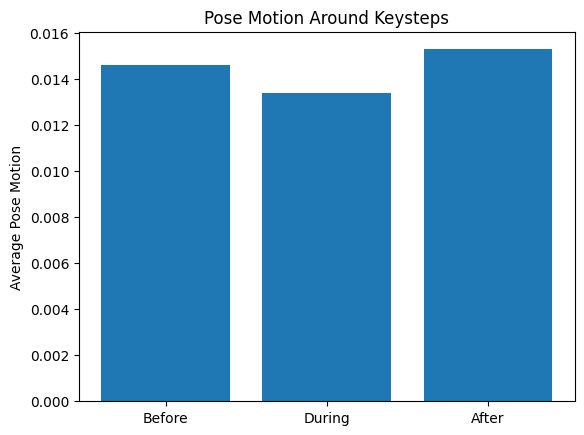

In [19]:
# CAM 1
import matplotlib.pyplot as plt

means = analysis_df[["before_motion", "during_motion", "after_motion"]].mean()

plt.bar(["Before", "During", "After"], means)
plt.ylabel("Average Pose Motion")
plt.title("Pose Motion Around Keysteps")

plt.show()

## Start Boundary Analysis

In [194]:
start_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid
    start_time = row.start_sec

    cur_pose = pose_df[pose_df["take_uid"] == take_uid]

    window = cur_pose[(cur_pose["time"] >= start_time - 2) & (cur_pose["time"] <= start_time + 2)].copy()

    window["relative_time"] = window["time"] - start_time

    for pose_row in window.itertuples():
        start_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": pose_row.relative_time, "motion": pose_row.motion}]

In [195]:
start_df = pd.DataFrame(start_boundary)
start_df.head()

,take_uid,keystep,relative_time,motion
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.6,0.040767
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.8,0.026516
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,1.0,0.031439
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,1.2,0.016606
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,1.4,0.020814


In [196]:
start_df["time_bin"] = (start_df["relative_time"] * 5).round() / 5

In [197]:
start_avg = (start_df.groupby("time_bin")["motion"].mean().reset_index())

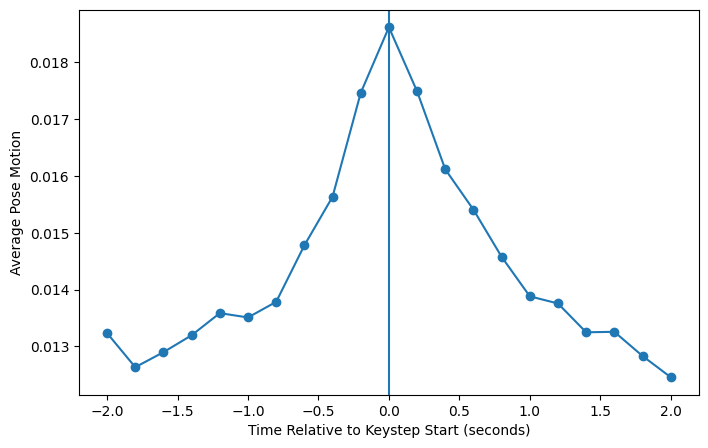

In [198]:
plt.figure(figsize=(8, 5))

plt.plot(start_avg["time_bin"], start_avg["motion"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep Start (seconds)")
plt.ylabel("Average Pose Motion")
plt.show()

In [199]:
keystep_effects = []

for row in all_examples.itertuples():

    cur_pose = pose_df[pose_df["take_uid"] == row.take_uid].copy()
    cur_pose["relative_time"] = (cur_pose["time"] - row.start_sec)
    boundary = cur_pose[(cur_pose["relative_time"] >= -0.4) & (cur_pose["relative_time"] <= 0.4)]["motion"].mean()
    context = cur_pose[((cur_pose["relative_time"] >= -2) & (cur_pose["relative_time"] <= -1)) | ( (cur_pose["relative_time"] >= 1) & (cur_pose["relative_time"] <= 2))]["motion"].mean()

    keystep_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "boundary_motion": boundary, "context_motion": context,"boundary_effect": boundary - context}]

keystep_effect_df = pd.DataFrame(keystep_effects)

In [200]:
keystep_summary = keystep_effect_df.groupby("keystep").agg(boundary_effect=("boundary_effect", "mean"), count=("boundary_effect", "count")).reset_index()

keystep_summary = keystep_summary[keystep_summary["count"] >= 10]

keystep_summary = keystep_summary.sort_values("boundary_effect", ascending=False)

keystep_summary.head(20)

,keystep,boundary_effect,count
156,Get tomato,0.013670,10
95,Get a bowl,0.011198,19
310,fold the instruction paper,0.010655,12
121,Get eggs,0.010214,12
304,Wipe hands,0.009735,13
49,Check if the patient is responding at all,0.009578,12
265,Tap patient to confirm consciousness,0.008591,25
139,Get plate,0.008455,15
174,Loosen both axle nuts using a wrench,0.008239,34
60,Connect the brake noodle,0.008071,16


In [201]:
pose_start_summary = keystep_summary.copy()

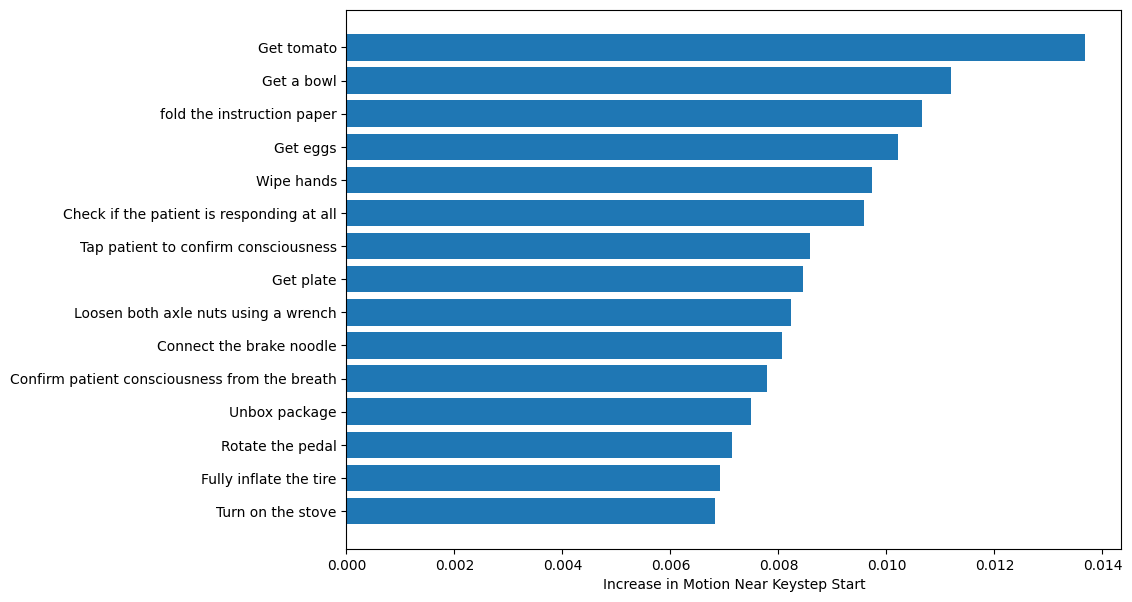

In [27]:
top = keystep_summary.head(15)

plt.figure(figsize=(10, 7))

plt.barh(top["keystep"][::-1], top["boundary_effect"][::-1])

plt.xlabel("Increase in Motion Near Keystep Start")

plt.show()

In [28]:
#START
joint_effects = []
for row in tqdm(all_examples.itertuples()):
    cur_pose = pose_df[pose_df["take_uid"] == row.take_uid].copy()
    cur_pose["relative_time"] = cur_pose["time"] - row.start_sec

    for joint in joint_names:
        boundary = cur_pose[(cur_pose["relative_time"] >=-0.4) & (cur_pose["relative_time"] <=0.4)][joint].mean()

        context = cur_pose[((cur_pose["relative_time"] >=-2) & (cur_pose["relative_time"] <=-1)) | ((cur_pose["relative_time"] >=1) & (cur_pose["relative_time"] <=2))][joint].mean()

        joint_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "joint": joint, "boundary": boundary, "context": context, "boundary_effect": boundary - context}]

joint_effects_df = pd.DataFrame(joint_effects)
joint_effects_df.head()

2785it [00:28, 97.09it/s]


,take_uid,keystep,joint,boundary,context,boundary_effect
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,nose,NaN,0.008845,NaN
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,left_eye,NaN,0.008089,NaN
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,right_eye,NaN,0.008402,NaN
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,left_ear,NaN,0.007465,NaN
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,right_ear,NaN,0.008484,NaN


In [29]:
joint_summary = (joint_effects_df.groupby("joint").agg(boundary_effect = ("boundary_effect", "mean"), count = ("boundary_effect", "count")).reset_index())
joint_summary = joint_summary.sort_values("boundary_effect", ascending=False)
joint_summary

,joint,boundary_effect,count
16,right_wrist,0.007232,2663
7,left_wrist,0.007178,2663
5,left_knee,0.005606,2663
14,right_knee,0.005079,2663
0,left_ankle,0.004877,2663
9,right_ankle,0.004715,2663
2,left_elbow,0.004453,2663
11,right_elbow,0.004203,2663
4,left_hip,0.003447,2663
3,left_eye,0.003328,2663


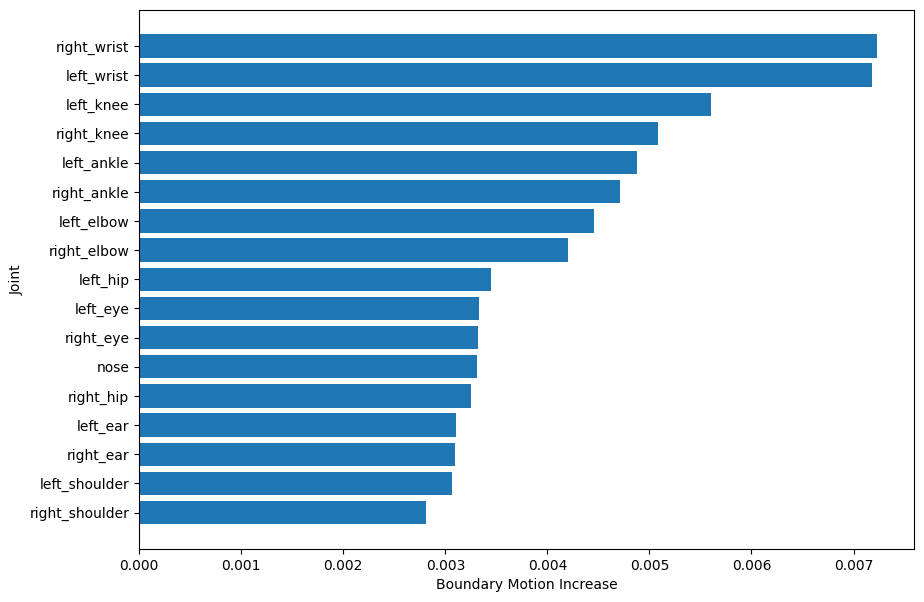

In [30]:
plt.figure(figsize=(10,7))

joint_plot = joint_summary.sort_values("boundary_effect")

plt.barh(joint_plot["joint"], joint_plot["boundary_effect"])
plt.xlabel("Boundary Motion Increase")
plt.ylabel("Joint")

plt.show()

In [31]:
# Key step and joint correlation
keystep_joint = (joint_effects_df.groupby(["keystep", "joint"])["boundary_effect"].mean().reset_index())
keystep_joint

,keystep,joint,boundary_effect
0,Add a mix of ingredients to a bowl,left_ankle,-0.001664
1,Add a mix of ingredients to a bowl,left_ear,0.000010
2,Add a mix of ingredients to a bowl,left_elbow,0.000963
3,Add a mix of ingredients to a bowl,left_eye,-0.000798
4,Add a mix of ingredients to a bowl,left_hip,0.000942
...,...,...,...
5299,return the test kit items back into the box,right_eye,0.003043
5300,return the test kit items back into the box,right_hip,0.007867
5301,return the test kit items back into the box,right_knee,0.013205
5302,return the test kit items back into the box,right_shoulder,0.003775


In [32]:
keystep_joint_matrix = keystep_joint.pivot(index="keystep", columns="joint", values="boundary_effect")
keystep_joint_matrix

joint,left_ankle,left_ear,left_elbow,left_eye,left_hip,left_knee,left_shoulder,left_wrist,nose,right_ankle,right_ear,right_elbow,right_eye,right_hip,right_knee,right_shoulder,right_wrist
keystep,,,,,,,,,,,,,,,,,
Add a mix of ingredients to a bowl,-0.001664,0.000010,0.000963,-0.000798,0.000942,-0.001516,0.001048,-0.000285,-0.000924,-0.002661,-0.000941,0.006297,-0.001030,0.002171,-0.002098,0.001210,0.004456
Add almonds,-0.003415,0.002397,-0.002156,0.003842,0.001862,-0.010832,0.003955,0.003207,0.003831,-0.001757,-0.000558,0.003625,0.002112,0.001021,0.000331,0.002027,0.005144
Add black pepper,-0.000205,0.004467,0.014146,0.007435,0.003579,0.001954,0.005575,0.018393,0.006789,0.011059,0.003610,0.004705,0.006664,0.004134,0.007394,0.002860,0.020342
Add butter to skillet,0.000021,-0.014317,-0.012016,-0.011684,-0.019317,-0.002907,-0.012724,-0.012621,-0.010940,-0.008547,-0.011998,-0.001846,-0.011419,-0.019158,-0.008019,-0.007227,-0.010320
Add cardamom to tea,-0.001226,0.001334,-0.001092,0.000414,-0.000083,-0.000889,0.000067,-0.005223,0.000185,-0.002006,-0.000395,-0.002561,-0.000035,-0.001173,-0.002496,-0.000509,-0.006192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
brush the chain while it remains stationary,0.002145,-0.000337,-0.000755,0.000431,-0.001799,-0.000058,-0.001486,0.004044,0.000875,-0.000682,0.000872,0.007730,0.000910,-0.001299,-0.001136,0.000446,0.013854
carefully open the test tube seal paper,0.006706,-0.000016,0.001323,0.000444,0.003538,0.007278,0.000102,0.001978,0.000631,0.006249,-0.000135,0.001716,0.000507,0.003011,0.007921,-0.000205,0.007069
cover the test tube,0.006617,0.002446,0.003273,0.003061,0.005018,0.007961,0.002227,0.005263,0.003091,0.007413,0.003196,0.003965,0.003168,0.004311,0.008015,0.003010,0.011274


In [33]:
top_keysteps = keystep_summary.head(15)["keystep"].tolist()
keystep_joint_matrix = keystep_joint_matrix.loc[keystep_joint_matrix.index.isin(top_keysteps)]
keystep_joint_matrix

joint,left_ankle,left_ear,left_elbow,left_eye,left_hip,left_knee,left_shoulder,left_wrist,nose,right_ankle,right_ear,right_elbow,right_eye,right_hip,right_knee,right_shoulder,right_wrist
keystep,,,,,,,,,,,,,,,,,
Check if the patient is responding at all,0.006042,0.015329,0.011466,0.015741,0.004994,0.004856,0.010821,0.012108,0.015360,0.005995,0.014335,0.005360,0.015472,0.004589,0.005918,0.010488,0.003954
Confirm patient consciousness from the breath,0.007967,0.008172,0.006452,0.007393,0.009361,0.006335,0.010156,0.003366,0.007634,0.006495,0.009001,0.007077,0.008259,0.011885,0.005553,0.011266,0.006016
Connect the brake noodle,0.002918,0.007572,0.006314,0.008368,0.003605,0.004109,0.005873,0.013408,0.008459,0.005487,0.008313,0.012152,0.008357,0.006237,0.006368,0.008540,0.021135
Fully inflate the tire,0.006236,0.007321,0.008582,0.007352,0.005279,0.006815,0.006343,0.013410,0.007218,0.005828,0.006523,0.005765,0.007052,0.004006,0.005684,0.004008,0.010071
Get a bowl,0.005393,0.014941,0.008313,0.014657,0.012076,0.008696,0.010841,0.009281,0.014414,0.009393,0.013195,0.008869,0.014101,0.012357,0.009383,0.008485,0.015978
Get eggs,0.013631,0.004184,0.011136,0.003352,0.018550,0.024327,0.005493,0.003813,0.002883,0.009220,0.003064,0.010065,0.002705,0.015969,0.025145,0.003864,0.016229
Get plate,0.009022,0.007824,0.002132,0.007697,0.007393,0.010001,0.005993,0.010896,0.008415,0.010126,0.009463,0.005964,0.008336,0.004206,0.008569,0.006159,0.021543
Get tomato,0.006453,0.013576,0.018719,0.013317,0.012972,0.008831,0.014016,0.020366,0.012959,0.009275,0.014032,0.014923,0.013373,0.013103,0.008575,0.012782,0.025113
Loosen both axle nuts using a wrench,0.008449,0.008543,0.009428,0.009674,0.007246,0.011125,0.008338,0.013166,0.009608,0.007041,0.007558,0.005473,0.009180,0.004585,0.008659,0.005410,0.006584


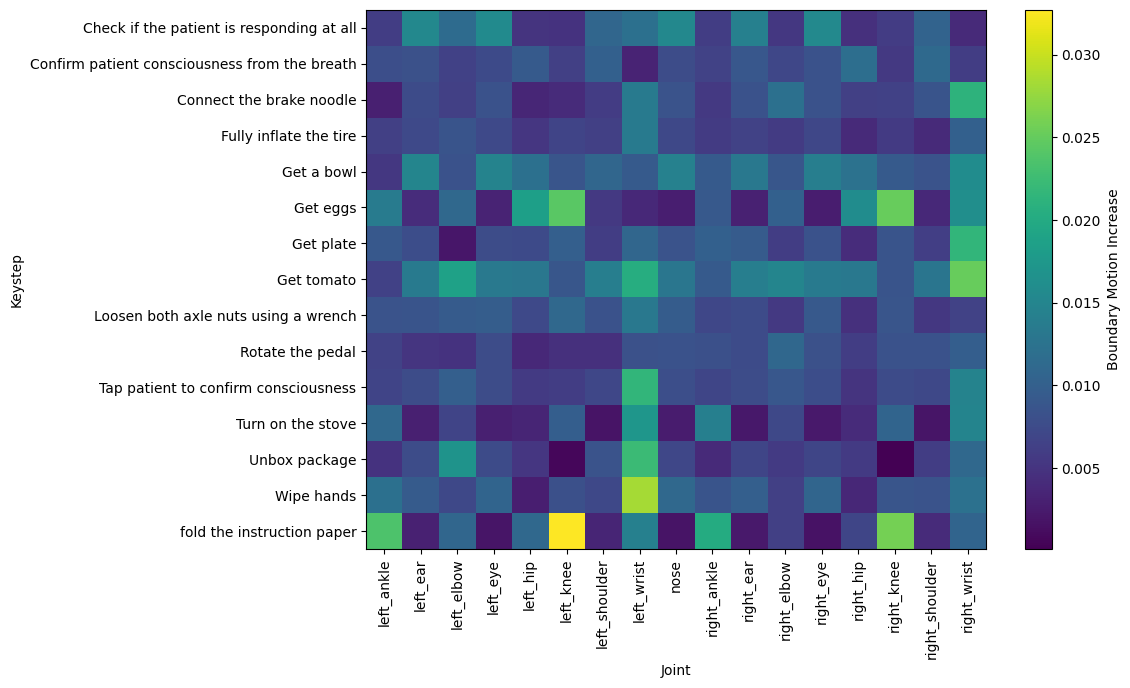

In [34]:
plt.figure(figsize=(10, 7))
plt.imshow(keystep_joint_matrix, aspect = "auto")
plt.colorbar(label = "Boundary Motion Increase")

plt.xticks(range(len(keystep_joint_matrix.columns)), keystep_joint_matrix.columns, rotation = 90)

plt.yticks(range(len(keystep_joint_matrix.index)), keystep_joint_matrix.index)

plt.xlabel("Joint")
plt.ylabel("Keystep")

plt.tight_layout
plt.show()

## End Boundary Analysis

In [202]:
end_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid
    end_time = row.end_sec

    cur_pose = pose_df[pose_df["take_uid"] == take_uid]

    window = cur_pose[(cur_pose["time"] >= end_time - 2) & (cur_pose["time"] <= end_time + 2)].copy()

    window["relative_time"] = window["time"] - end_time

    for pose_row in window.itertuples():
        end_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": pose_row.relative_time, "motion": pose_row.motion}]

In [203]:
end_df = pd.DataFrame(end_boundary)
end_df.head()

,take_uid,keystep,relative_time,motion
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.843,0.007372
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.643,0.003398
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.443,0.001594
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.243,0.005899
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.043,0.001382


In [204]:
end_df["time_bin"] = (end_df["relative_time"] * 5).round() / 5

In [205]:
end_avg = (end_df.groupby("time_bin")["motion"].mean().reset_index())

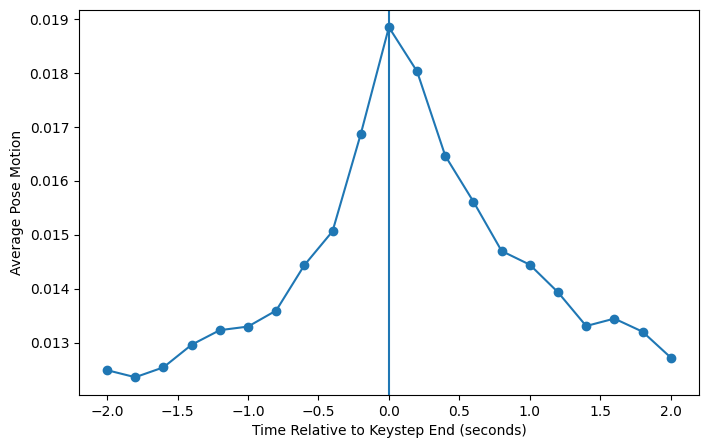

In [206]:
plt.figure(figsize=(8, 5))

plt.plot(end_avg["time_bin"], end_avg["motion"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep End (seconds)")
plt.ylabel("Average Pose Motion")
plt.show()

In [207]:
keystep_effects = []

for row in all_examples.itertuples():

    cur_pose = pose_df[pose_df["take_uid"] == row.take_uid].copy()
    cur_pose["relative_time"] = (cur_pose["time"] - row.end_sec)
    boundary = cur_pose[(cur_pose["relative_time"] >= -0.4) & (cur_pose["relative_time"] <= 0.4)]["motion"].mean()
    context = cur_pose[((cur_pose["relative_time"] >= -2) & (cur_pose["relative_time"] <= -1)) | ( (cur_pose["relative_time"] >= 1) & (cur_pose["relative_time"] <= 2))]["motion"].mean()

    keystep_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "boundary_motion": boundary, "context_motion": context,"boundary_effect": boundary - context}]

keystep_effect_df = pd.DataFrame(keystep_effects)

In [208]:
keystep_summary = keystep_effect_df.groupby("keystep").agg(boundary_effect=("boundary_effect", "mean"), count=("boundary_effect", "count")).reset_index()

keystep_summary = keystep_summary[keystep_summary["count"] >= 10]

keystep_summary = keystep_summary.sort_values("boundary_effect", ascending=False)

keystep_summary.head(20)

,keystep,boundary_effect,count
59,Confirm patient consciousness from the breath,0.017033,21
49,Check if the patient is responding at all,0.013893,11
197,Press hard at a rate of 100 to 120 compression...,0.010424,35
73,Cut onions,0.010107,13
303,Whisk until the egg whites and yolks are well ...,0.009009,27
70,Cut cucumber,0.008782,25
264,Stop timer,0.008736,12
79,Dispose waste,0.008435,87
246,Set a timer,0.008418,18
104,Get appropriate wrenches,0.007807,32


In [209]:
pose_end_summary = keystep_summary.copy()

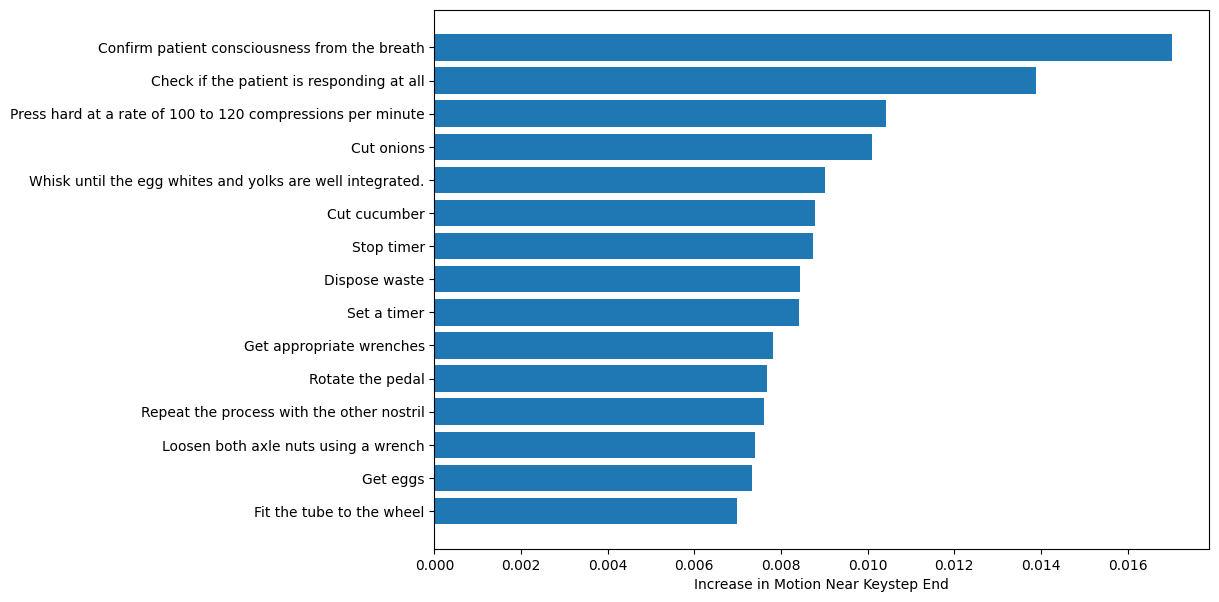

In [42]:
top = keystep_summary.head(15)

plt.figure(figsize=(10, 7))

plt.barh(top["keystep"][::-1], top["boundary_effect"][::-1])

plt.xlabel("Increase in Motion Near Keystep End")

plt.show()

In [43]:
#END
joint_effects = []
for row in tqdm(all_examples.itertuples()):
    cur_pose = pose_df[pose_df["take_uid"] == row.take_uid].copy()
    cur_pose["relative_time"] = cur_pose["time"] - row.end_sec

    for joint in joint_names:
        boundary = cur_pose[(cur_pose["relative_time"] >=-0.4) & (cur_pose["relative_time"] <=0.4)][joint].mean()

        context = cur_pose[((cur_pose["relative_time"] >=-2) & (cur_pose["relative_time"] <=-1)) | ((cur_pose["relative_time"] >=1) & (cur_pose["relative_time"] <=2))][joint].mean()

        joint_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "joint": joint, "boundary": boundary, "context": context, "boundary_effect": boundary - context}]

joint_effects_df = pd.DataFrame(joint_effects)
joint_effects_df.head()

2785it [00:28, 97.01it/s]


,take_uid,keystep,joint,boundary,context,boundary_effect
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,nose,0.004762,0.001478,0.003283
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,left_eye,0.004792,0.001595,0.003197
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,right_eye,0.004423,0.001589,0.002834
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,left_ear,0.004033,0.001575,0.002457
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,right_ear,0.003205,0.001620,0.001586


In [44]:
joint_summary = (joint_effects_df.groupby("joint").agg(boundary_effect = ("boundary_effect", "mean"), count = ("boundary_effect", "count")).reset_index())
joint_summary = joint_summary.sort_values("boundary_effect", ascending=False)
joint_summary

,joint,boundary_effect,count
16,right_wrist,0.007244,2690
7,left_wrist,0.007236,2690
5,left_knee,0.005856,2690
14,right_knee,0.005402,2690
0,left_ankle,0.004999,2690
9,right_ankle,0.004759,2690
2,left_elbow,0.004241,2690
11,right_elbow,0.004149,2690
12,right_eye,0.003534,2690
8,nose,0.003497,2690


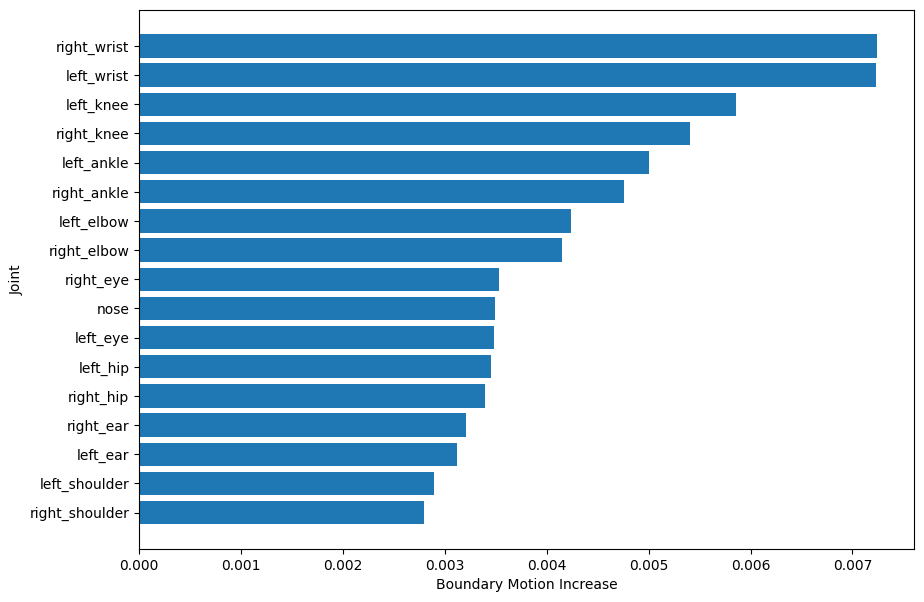

In [45]:
plt.figure(figsize=(10,7))

joint_plot = joint_summary.sort_values("boundary_effect")

plt.barh(joint_plot["joint"], joint_plot["boundary_effect"])
plt.xlabel("Boundary Motion Increase")
plt.ylabel("Joint")

plt.show()

In [46]:
# Key step and joint correlation
keystep_joint = (joint_effects_df.groupby(["keystep", "joint"])["boundary_effect"].mean().reset_index())
keystep_joint

,keystep,joint,boundary_effect
0,Add a mix of ingredients to a bowl,left_ankle,0.010733
1,Add a mix of ingredients to a bowl,left_ear,0.005238
2,Add a mix of ingredients to a bowl,left_elbow,0.010501
3,Add a mix of ingredients to a bowl,left_eye,0.010885
4,Add a mix of ingredients to a bowl,left_hip,0.005237
...,...,...,...
5299,return the test kit items back into the box,right_eye,0.001511
5300,return the test kit items back into the box,right_hip,0.004284
5301,return the test kit items back into the box,right_knee,0.010607
5302,return the test kit items back into the box,right_shoulder,0.001137


In [47]:
keystep_joint_matrix = keystep_joint.pivot(index="keystep", columns="joint", values="boundary_effect")
keystep_joint_matrix

joint,left_ankle,left_ear,left_elbow,left_eye,left_hip,left_knee,left_shoulder,left_wrist,nose,right_ankle,right_ear,right_elbow,right_eye,right_hip,right_knee,right_shoulder,right_wrist
keystep,,,,,,,,,,,,,,,,,
Add a mix of ingredients to a bowl,0.010733,0.005238,0.010501,0.010885,0.005237,0.013380,0.004582,0.026916,0.012668,0.005395,0.009270,0.008942,0.012705,0.007008,0.007708,0.005910,0.014934
Add almonds,-0.008608,-0.006926,-0.002905,-0.006458,-0.004394,0.002415,-0.002523,-0.014258,-0.005987,-0.013178,-0.004090,-0.006061,-0.004797,-0.002640,-0.001595,-0.001584,-0.014360
Add black pepper,0.004476,0.003783,-0.001531,0.004943,0.009007,0.003242,-0.001756,-0.013746,0.003597,0.003680,0.003373,-0.004633,0.005242,0.005909,0.006147,-0.004766,0.014001
Add butter to skillet,0.007042,-0.002104,0.005245,-0.001893,-0.009100,-0.006699,-0.000276,0.027952,-0.002351,-0.006457,-0.008251,-0.020017,-0.005208,-0.005682,-0.018533,-0.003394,-0.027404
Add cardamom to tea,0.016839,0.004423,0.008018,0.005713,0.010340,0.013173,0.004084,0.010534,0.005787,0.017829,0.006900,0.009654,0.006561,0.011537,0.012019,0.007102,0.021687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
brush the chain while it remains stationary,-0.000021,0.001297,0.003688,0.000670,0.000898,-0.000412,0.001868,0.004600,0.000555,0.003038,0.002370,0.002208,0.001065,0.000655,0.001069,0.002122,0.008183
carefully open the test tube seal paper,0.006243,0.001171,0.002599,0.001514,0.004312,0.011809,0.000777,0.006410,0.001530,0.005363,0.001180,0.006825,0.001414,0.004559,0.010800,0.001859,0.008996
cover the test tube,0.008430,0.001422,0.004239,0.001722,0.002720,0.011894,0.001465,0.007577,0.001703,0.009021,0.001653,0.005811,0.001735,0.002509,0.011922,0.002005,0.009963


In [48]:
top_keysteps = keystep_summary.head(15)["keystep"].tolist()
keystep_joint_matrix = keystep_joint_matrix.loc[keystep_joint_matrix.index.isin(top_keysteps)]
keystep_joint_matrix

joint,left_ankle,left_ear,left_elbow,left_eye,left_hip,left_knee,left_shoulder,left_wrist,nose,right_ankle,right_ear,right_elbow,right_eye,right_hip,right_knee,right_shoulder,right_wrist
keystep,,,,,,,,,,,,,,,,,
Check if the patient is responding at all,0.011451,0.018081,0.012763,0.017708,0.011566,0.011110,0.016527,0.007715,0.017510,0.007809,0.017248,0.017941,0.017614,0.009354,0.009846,0.018441,0.013504
Confirm patient consciousness from the breath,0.009102,0.022073,0.014526,0.025226,0.013811,0.009907,0.016711,0.018913,0.025348,0.007734,0.021227,0.014303,0.025448,0.014440,0.012701,0.016752,0.021339
Cut cucumber,0.008367,0.008589,0.008218,0.008889,0.006931,0.010903,0.007674,0.009584,0.009084,0.007338,0.007193,0.007918,0.008604,0.007099,0.009712,0.007055,0.016142
Cut onions,0.008175,0.010107,0.010649,0.010326,0.004552,0.004108,0.007138,0.015549,0.010801,0.012526,0.011542,0.014701,0.010573,0.004168,0.010069,0.009466,0.017371
Dispose waste,0.011705,0.003031,0.005918,0.005018,0.007000,0.016164,0.003008,0.011528,0.005673,0.012274,0.005949,0.006426,0.006095,0.006566,0.017025,0.004600,0.015421
Fit the tube to the wheel,0.004442,0.009665,0.006769,0.009973,0.003753,0.006146,0.006856,0.010593,0.009577,0.003866,0.009037,0.005480,0.009855,0.004278,0.004464,0.005739,0.008069
Get appropriate wrenches,0.004912,0.007336,0.008727,0.008635,0.006530,0.007561,0.005321,0.012144,0.008552,0.007479,0.007751,0.008454,0.008735,0.006876,0.008541,0.005004,0.010166
Get eggs,0.007112,0.003449,0.009962,0.004401,0.012094,0.008709,0.004501,0.008101,0.004803,0.005937,0.003629,0.009120,0.004394,0.010249,0.005290,0.003321,0.019653
Loosen both axle nuts using a wrench,0.005048,0.006163,0.006365,0.007536,0.005311,0.008477,0.006234,0.008978,0.008269,0.004217,0.007124,0.008200,0.008042,0.005405,0.007464,0.007607,0.015315


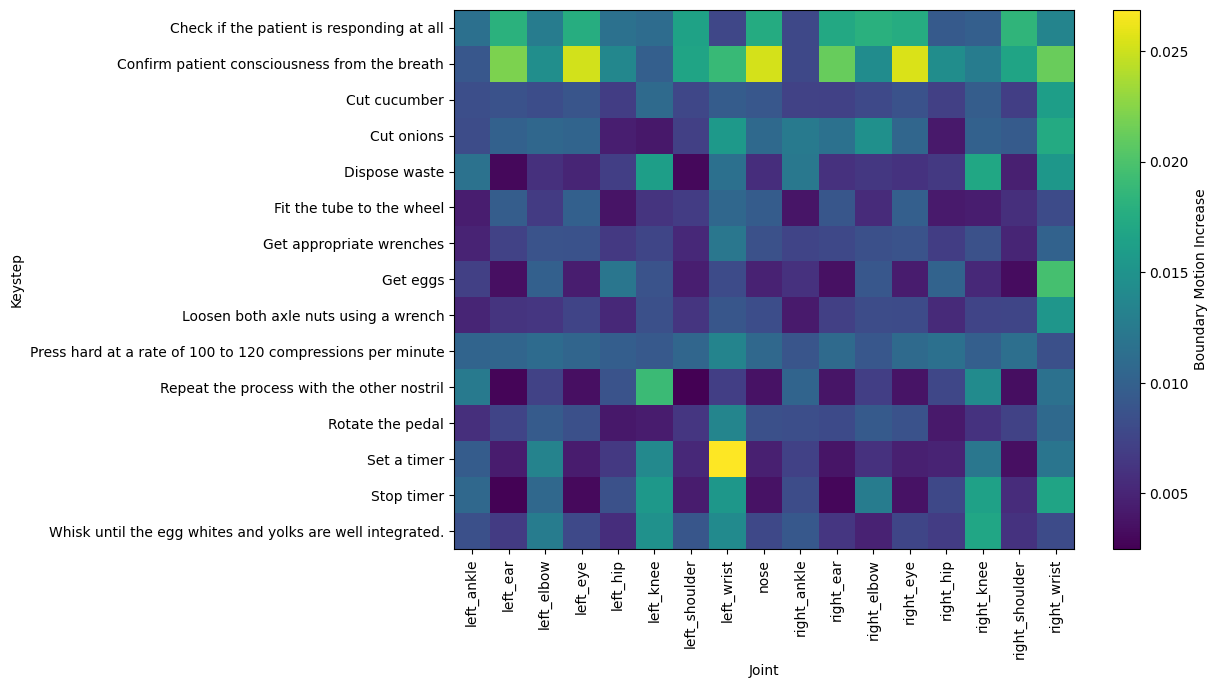

In [49]:
plt.figure(figsize=(10, 7))
plt.imshow(keystep_joint_matrix, aspect = "auto")
plt.colorbar(label = "Boundary Motion Increase")

plt.xticks(range(len(keystep_joint_matrix.columns)), keystep_joint_matrix.columns, rotation = 90)

plt.yticks(range(len(keystep_joint_matrix.index)), keystep_joint_matrix.index)

plt.xlabel("Joint")
plt.ylabel("Keystep")

plt.tight_layout
plt.show()

## Start vs. End vs. Random

In [50]:
start_df, end_df

(                                   take_uid                   keystep  \
 0      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 1      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 2      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 3      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 4      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 ...                                     ...                       ...   
 52142  01b0a6e3-04ce-4f0d-8df4-b3d3c1508780  Transfer food to a plate   
 52143  01b0a6e3-04ce-4f0d-8df4-b3d3c1508780  Transfer food to a plate   
 52144  01b0a6e3-04ce-4f0d-8df4-b3d3c1508780  Transfer food to a plate   
 52145  01b0a6e3-04ce-4f0d-8df4-b3d3c1508780  Transfer food to a plate   
 52146  01b0a6e3-04ce-4f0d-8df4-b3d3c1508780  Transfer food to a plate   
 
        relative_time    motion  time_bin  
 0              0.600  0.040767       0.6  
 1              0.800 

In [51]:
random_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid

    cur_pose = pose_df[pose_df["take_uid"] == take_uid]

    if len(cur_pose) == 0: continue


    min_time = cur_pose["time"].min() + 2
    max_time = cur_pose["time"].max() - 2

    if min_time >= max_time: continue

    random_time = np.random.uniform(min_time, max_time)

    window = cur_pose[(cur_pose["time"] >= random_time - 2) & (cur_pose["time"] <= random_time + 2)].copy()

    window["relative_time"] = window["time"] - random_time

    for pose_row in window.itertuples():
        random_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": pose_row.relative_time, "motion": pose_row.motion}]

In [52]:
random_df = pd.DataFrame(random_boundary)
random_df.head()

,take_uid,keystep,relative_time,motion
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.93168,0.007524
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.73168,0.002408
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.53168,0.009222
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.33168,0.005540
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.13168,0.013135


In [53]:
random_df["time_bin"] = (random_df["relative_time"] * 5).round() / 5

In [54]:
random_avg = (random_df.groupby("time_bin")["motion"].mean().reset_index())

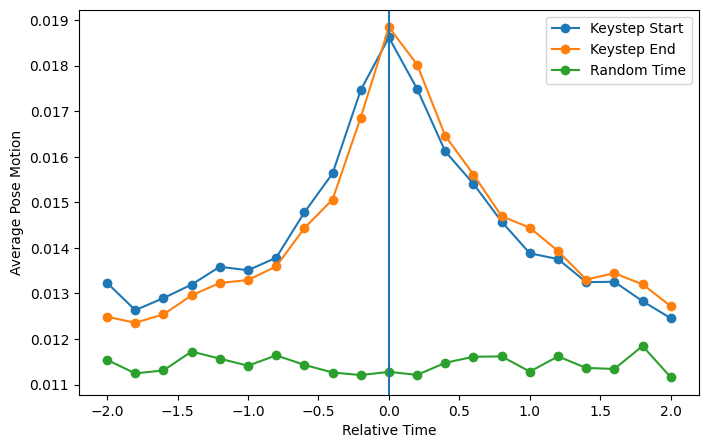

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(start_avg["time_bin"], start_avg["motion"], marker="o", label = "Keystep Start")
plt.plot(end_avg["time_bin"], end_avg["motion"], marker="o", label = "Keystep End")
plt.plot(random_avg["time_bin"], random_avg["motion"], marker="o", label = "Random Time")


plt.axvline(0)

plt.xlabel("Relative Time")
plt.ylabel("Average Pose Motion")
plt.legend()
plt.show()

# Gaze Analysis

In [56]:
all_gaze = []

In [58]:
for take_uid in tqdm(all_examples["take_uid"].unique()):
        
    take_examples = all_examples[all_examples["take_uid"]==take_uid]
    if pd.isna(take_examples.iloc[0].exo_videos): continue

    if not take_examples.iloc[0].gaze_personalized_exists: continue

    gaze_path = take_examples.iloc[0].gaze_personalized_file

    if pd.isna(gaze_path): continue
    
    cur_gaze = pd.read_csv(gaze_path)
    if len(cur_gaze) < 2: continue

    prev_yaw = None
    prev_pitch = None
    prev_time = None

    first_timestamp = cur_gaze.iloc[0].tracking_timestamp_us

    for row in cur_gaze.itertuples():
        time = (row.tracking_timestamp_us - first_timestamp)/1000000

        yaw = (row.left_yaw_rads_cpf + row.right_yaw_rads_cpf)/2
        pitch = row.pitch_rads_cpf

        if pd.isna(yaw) or pd.isna(pitch):
            prev_yaw = None
            prev_pitch = None
            prev_time = None
            continue
        if prev_yaw is None:
            prev_yaw = yaw
            prev_pitch = pitch
            prev_time = time
            continue
        time_diff = time - prev_time
        if time_diff <= 0:
            continue

        gaze_diff = math.sqrt((yaw - prev_yaw)**2 + (pitch - prev_pitch)**2)
        gaze_vel = gaze_diff / time_diff

        all_gaze += [{"take_uid":take_uid, "time":time, "yaw":yaw, "pitch":pitch, "gaze_diff":gaze_diff, "gaze_vel":gaze_vel}]

        prev_yaw = yaw
        prev_pitch = pitch
        prev_time = time

100%|███████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 379.32it/s]


In [59]:
gaze_df = pd.DataFrame(all_gaze)
gaze_df.head()

,take_uid,time,yaw,pitch,gaze_diff,gaze_vel
0,80f65504-a37a-4c84-8a19-df3bba123326,0.099984,0.080193,0.089557,0.297773,2.978209
1,80f65504-a37a-4c84-8a19-df3bba123326,0.199968,0.066094,0.069041,0.024894,0.248982
2,80f65504-a37a-4c84-8a19-df3bba123326,0.299952,0.072592,0.095780,0.027517,0.275216
3,80f65504-a37a-4c84-8a19-df3bba123326,0.399936,0.072368,0.088451,0.007332,0.073332
4,80f65504-a37a-4c84-8a19-df3bba123326,0.499920,0.102925,0.091485,0.030707,0.307115


In [60]:
gaze_df.to_csv("gaze_motion.csv", index=False)

In [62]:
# Spread of gaze
gaze_df["spread"] = np.nan
for take_uid in tqdm(all_examples["take_uid"].unique()):
    inds = gaze_df[gaze_df["take_uid"]==take_uid].index
    cur_gaze = gaze_df.loc[inds]

    yaw_std = cur_gaze["yaw"].rolling(5, center=True).std()
    pitch_std = cur_gaze["pitch"].rolling(5, center=True).std()

    gaze_df.loc[inds, "spread"] = np.sqrt(yaw_std**2 + pitch_std**2)


100%|███████████████████████████████████████████████████████████████████████████████| 216/216 [00:00<00:00, 257.96it/s]


In [63]:
analysis = []
for row in all_examples.itertuples():
    take_uid = row.take_uid
    start_time = row.start_sec
    end_time = row.end_sec

    keystep = row.keystep_name

    cur_gaze = gaze_df[gaze_df["take_uid"]==take_uid]
    before = cur_gaze[(cur_gaze["time"] >= start_time - 2) & (cur_gaze["time"] < start_time)]
    during = cur_gaze[(cur_gaze["time"] >= start_time) & (cur_gaze["time"] <= end_time)]
    after = cur_gaze[(cur_gaze["time"] > end_time) & (cur_gaze["time"] <= end_time + 2)]

    before_vel = before["gaze_vel"].mean()
    during_vel = during["gaze_vel"].mean()
    after_vel = after["gaze_vel"].mean()

    before_spread = before["spread"].mean()
    during_spread = during["spread"].mean()
    after_spread = after["spread"].mean()

    analysis += [{"take_uid": take_uid, "keystep":keystep, "start_time":start_time, "end_time":end_time, "before_vel":before_vel, "during_vel":during_vel, "after_vel":after_vel, "before_spread":before_spread, "during_spread":during_spread, "after_spread":after_spread}]
    

In [64]:
analysis_df = pd.DataFrame(analysis)
analysis_df.head()

,take_uid,keystep,start_time,end_time,before_vel,during_vel,after_vel,before_spread,during_spread,after_spread
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.00000,27.64300,NaN,0.551574,0.330808,NaN,0.070850,0.039930
1,80f65504-a37a-4c84-8a19-df3bba123326,Read the instructions,44.51100,51.25484,0.646279,0.476707,1.249557,0.076577,0.056722,0.149278
2,80f65504-a37a-4c84-8a19-df3bba123326,Position the covid 19 test tube on the box,51.28817,58.42846,0.790173,0.801031,0.510799,0.087367,0.096392,0.053630
3,80f65504-a37a-4c84-8a19-df3bba123326,carefully open the test tube seal paper,58.52846,64.70245,0.326338,0.559688,0.812936,0.043528,0.068195,0.091545
4,80f65504-a37a-4c84-8a19-df3bba123326,Locate and unwrap the collection swab,64.76912,72.01571,0.673260,0.622129,0.434551,0.077772,0.072221,0.050757


In [65]:
analysis_df.to_csv("gaze_keystep_analysis_cam01.csv", index=False)

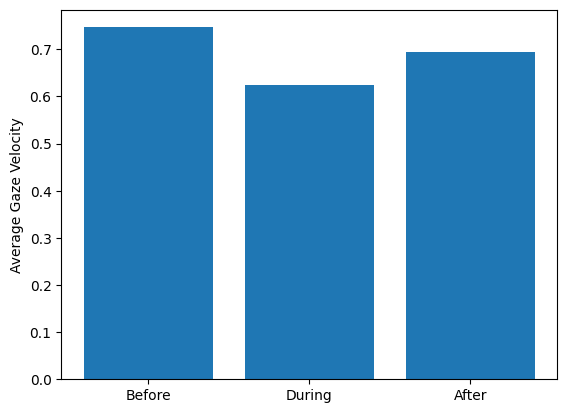

In [67]:
# Velocity
import matplotlib.pyplot as plt

means = analysis_df[["before_vel", "during_vel", "after_vel"]].mean()

plt.bar(["Before", "During", "After"], means)
plt.ylabel("Average Gaze Velocity")

plt.show()

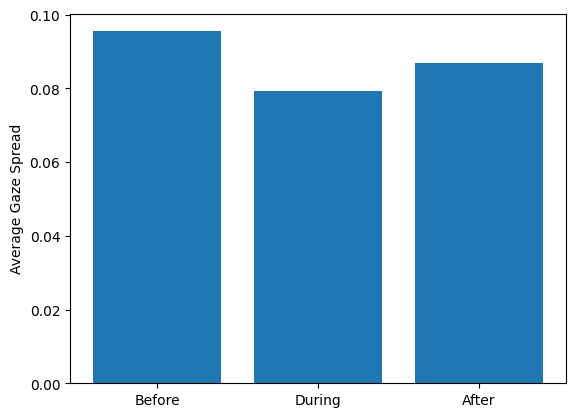

In [68]:
# Spread
import matplotlib.pyplot as plt

means = analysis_df[["before_spread", "during_spread", "after_spread"]].mean()

plt.bar(["Before", "During", "After"], means)
plt.ylabel("Average Gaze Spread")

plt.show()

## Start Boundary

In [210]:
start_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid
    start_time = row.start_sec

    cur_gaze = gaze_df[gaze_df["take_uid"] == take_uid]

    window = cur_gaze[(cur_gaze["time"] >= start_time - 2) & (cur_gaze["time"] <= start_time + 2)].copy()

    window["relative_time"] = window["time"] - start_time

    for gaze_row in window.itertuples():
        start_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": gaze_row.relative_time, "gaze_vel": gaze_row.gaze_vel, "spread": gaze_row.spread}]

In [211]:
start_df = pd.DataFrame(start_boundary)
start_df.head()

,take_uid,keystep,relative_time,gaze_vel,spread
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.099984,2.978209,NaN
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.199968,0.248982,NaN
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.299952,0.275216,0.017703
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.399936,0.073332,0.202916
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,0.499920,0.307115,0.304810


In [212]:
start_df["time_bin"] = (start_df["relative_time"] * 5).round() / 5

In [213]:
start_avg = (start_df.groupby("time_bin")["gaze_vel"].mean().reset_index())

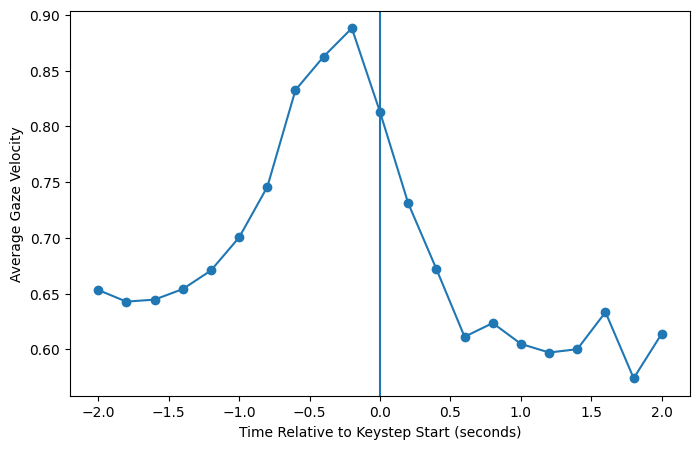

In [214]:
plt.figure(figsize=(8, 5))

plt.plot(start_avg["time_bin"], start_avg["gaze_vel"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep Start (seconds)")
plt.ylabel("Average Gaze Velocity")
plt.show()

In [215]:
start_spread_avg = (start_df.groupby("time_bin")["spread"].mean().reset_index())

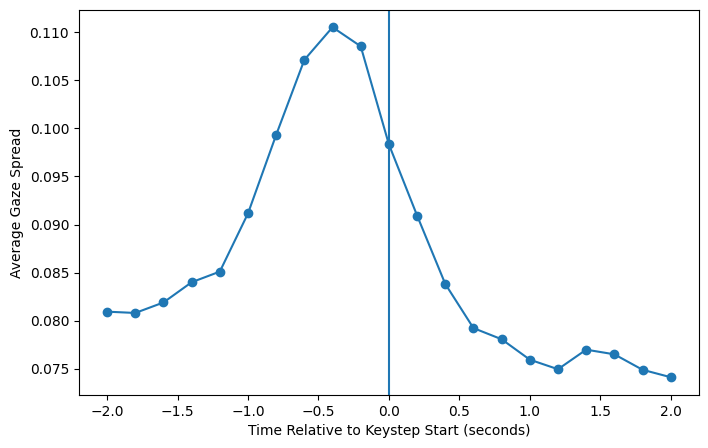

In [216]:
plt.figure(figsize=(8, 5))

plt.plot(start_spread_avg["time_bin"], start_spread_avg["spread"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep Start (seconds)")
plt.ylabel("Average Gaze Spread")
plt.show()

In [217]:
keystep_effects = []

for row in all_examples.itertuples():

    cur_gaze = gaze_df[gaze_df["take_uid"] == row.take_uid].copy()
    cur_gaze["relative_time"] = (cur_gaze["time"] - row.start_sec)
    boundary = cur_gaze[(cur_gaze["relative_time"] >= -0.4) & (cur_gaze["relative_time"] <= 0.4)]["gaze_vel"].mean()
    context = cur_gaze[((cur_gaze["relative_time"] >= -2) & (cur_gaze["relative_time"] <= -1)) | ( (cur_gaze["relative_time"] >= 1) & (cur_gaze["relative_time"] <= 2))]["gaze_vel"].mean()

    keystep_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "boundary_motion": boundary, "context_motion": context,"boundary_effect": boundary - context}]

keystep_effect_df = pd.DataFrame(keystep_effects)

In [218]:
keystep_summary = keystep_effect_df.groupby("keystep").agg(boundary_effect=("boundary_effect", "mean"), count=("boundary_effect", "count")).reset_index()

keystep_summary = keystep_summary[keystep_summary["count"] >= 10]

keystep_summary = keystep_summary.sort_values("boundary_effect", ascending=False)

keystep_summary.head(20)

,keystep,boundary_effect,count
256,Squeeze the brake,1.167368,10
106,Get bike tire lever,0.724329,10
104,Get appropriate wrenches,0.657773,15
88,Fit the tube to the wheel,0.486791,16
277,Unbox package,0.376718,21
246,Set a timer,0.366731,16
309,cover the test tube,0.347455,31
46,Check for any damage or splits in the thread,0.335110,10
174,Loosen both axle nuts using a wrench,0.325438,14
169,Locate and unwrap the collection swab,0.303533,27


In [219]:
gaze_start_summary = keystep_summary.copy()

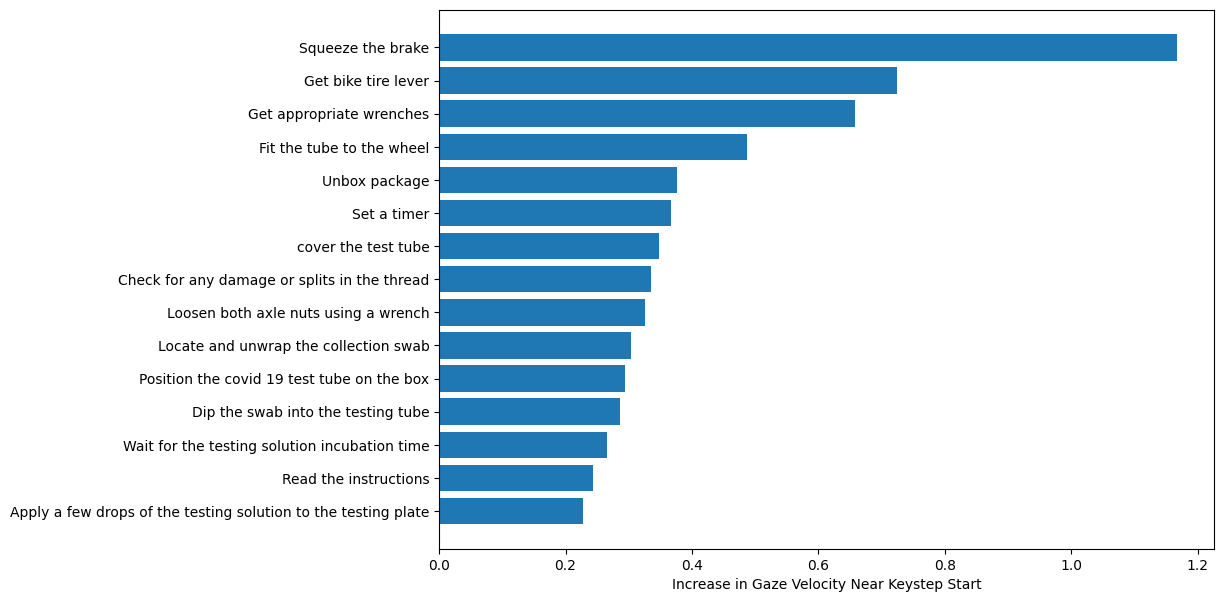

In [220]:
top = keystep_summary.head(15)

plt.figure(figsize=(10, 7))

plt.barh(top["keystep"][::-1], top["boundary_effect"][::-1])

plt.xlabel("Increase in Gaze Velocity Near Keystep Start")

plt.show()

## End Boundary

In [221]:
end_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid
    end_time = row.end_sec

    cur_gaze = gaze_df[gaze_df["take_uid"] == take_uid]

    window = cur_gaze[(cur_gaze["time"] >= end_time - 2) & (cur_gaze["time"] <= end_time + 2)].copy()

    window["relative_time"] = window["time"] - end_time

    for gaze_row in window.itertuples():
        end_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": gaze_row.relative_time, "gaze_vel": gaze_row.gaze_vel, "spread": gaze_row.spread}]

In [222]:
end_df = pd.DataFrame(end_boundary)
end_df.head()

,take_uid,keystep,relative_time,gaze_vel,spread
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.947112,0.293021,0.059076
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.847128,0.735331,0.058939
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.747144,0.218407,0.044186
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.647160,0.220712,0.016742
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.547176,0.067101,0.009468


In [223]:
end_df["time_bin"] = (end_df["relative_time"] * 5).round() / 5

In [224]:
end_avg = (end_df.groupby("time_bin")["gaze_vel"].mean().reset_index())

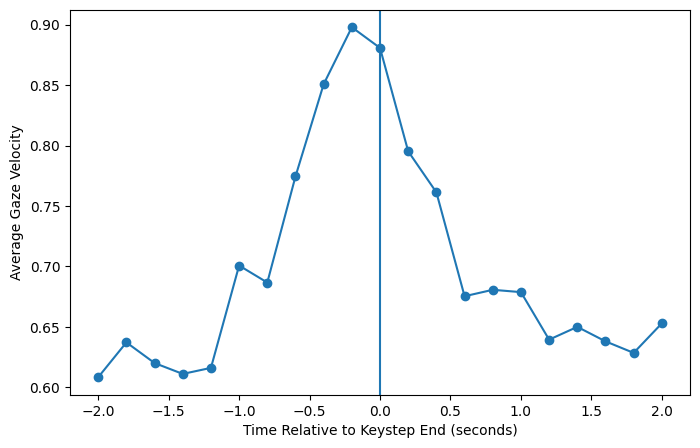

In [225]:
plt.figure(figsize=(8, 5))

plt.plot(end_avg["time_bin"], end_avg["gaze_vel"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep End (seconds)")
plt.ylabel("Average Gaze Velocity")
plt.show()

In [226]:
end_spread_avg = (end_df.groupby("time_bin")["spread"].mean().reset_index())

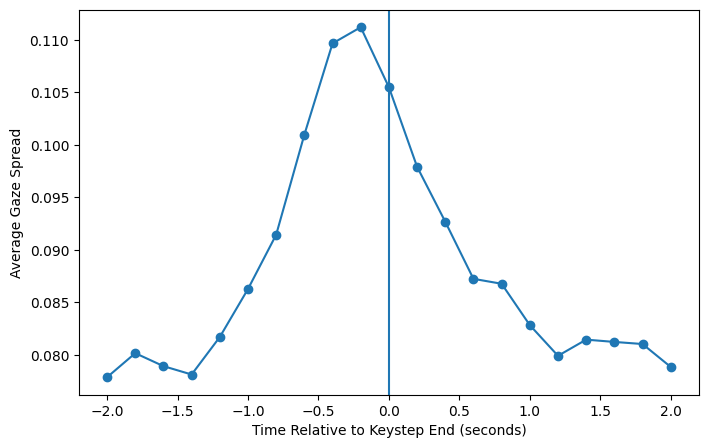

In [227]:
plt.figure(figsize=(8, 5))

plt.plot(end_spread_avg["time_bin"], end_spread_avg["spread"], marker="o")

plt.axvline(0)

plt.xlabel("Time Relative to Keystep End (seconds)")
plt.ylabel("Average Gaze Spread")
plt.show()

In [228]:
keystep_effects = []

for row in all_examples.itertuples():

    cur_gaze = gaze_df[gaze_df["take_uid"] == row.take_uid].copy()
    cur_gaze["relative_time"] = (cur_gaze["time"] - row.end_sec)
    boundary = cur_gaze[(cur_gaze["relative_time"] >= -0.4) & (cur_gaze["relative_time"] <= 0.4)]["gaze_vel"].mean()
    context = cur_gaze[((cur_gaze["relative_time"] >= -2) & (cur_gaze["relative_time"] <= -1)) | ( (cur_gaze["relative_time"] >= 1) & (cur_gaze["relative_time"] <= 2))]["gaze_vel"].mean()

    keystep_effects += [{"take_uid": row.take_uid, "keystep": row.keystep_name, "boundary_motion": boundary, "context_motion": context,"boundary_effect": boundary - context}]

keystep_effect_df = pd.DataFrame(keystep_effects)

In [229]:
keystep_summary = keystep_effect_df.groupby("keystep").agg(boundary_effect=("boundary_effect", "mean"), count=("boundary_effect", "count")).reset_index()

keystep_summary = keystep_summary[keystep_summary["count"] >= 10]

keystep_summary = keystep_summary.sort_values("boundary_effect", ascending=False)

keystep_summary.head(20)

,keystep,boundary_effect,count
265,Tap patient to confirm consciousness,0.741936,11
264,Stop timer,0.586359,10
79,Dispose waste,0.499354,62
53,Check the testing plate,0.389728,17
188,Position the covid 19 test tube on the box,0.370874,19
267,Tighten both axle nuts using a wrench,0.348855,24
93,Fully inflate the tire,0.346029,15
200,Pull the inner tube out,0.296795,19
228,Read the instructions,0.294300,93
198,Pull back and lift the bead out of the rim,0.274819,10


In [230]:
gaze_end_summary = keystep_summary.copy()

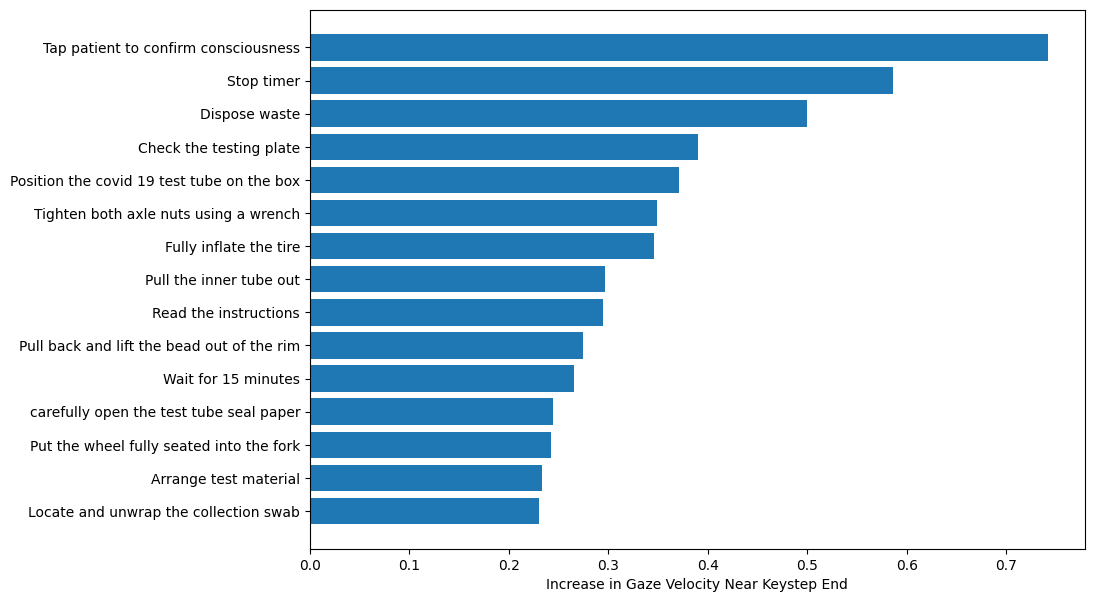

In [135]:
top = keystep_summary.head(15)

plt.figure(figsize=(10, 7))

plt.barh(top["keystep"][::-1], top["boundary_effect"][::-1])

plt.xlabel("Increase in Gaze Velocity Near Keystep End")

plt.show()

## Start vs. End vs. Random

In [136]:
start_df, end_df

(                                   take_uid                   keystep  \
 0      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 1      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 2      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 3      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 4      80f65504-a37a-4c84-8a19-df3bba123326     Arrange test material   
 ...                                     ...                       ...   
 44264  5d4abe32-590d-470d-8fd1-4585833afaad  Transfer food to a plate   
 44265  5d4abe32-590d-470d-8fd1-4585833afaad  Transfer food to a plate   
 44266  5d4abe32-590d-470d-8fd1-4585833afaad  Transfer food to a plate   
 44267  5d4abe32-590d-470d-8fd1-4585833afaad  Transfer food to a plate   
 44268  5d4abe32-590d-470d-8fd1-4585833afaad  Transfer food to a plate   
 
        relative_time  gaze_vel    spread  time_bin  
 0           0.099984  2.978209       NaN       0.0  
 1

In [137]:
random_boundary = []

for row in all_examples.itertuples():

    take_uid = row.take_uid

    cur_gaze = gaze_df[gaze_df["take_uid"] == take_uid]

    if len(cur_gaze) == 0: continue


    min_time = cur_gaze["time"].min() + 2
    max_time = cur_gaze["time"].max() - 2

    if min_time >= max_time: continue

    random_time = np.random.uniform(min_time, max_time)

    window = cur_gaze[(cur_gaze["time"] >= random_time - 2) & (cur_gaze["time"] <= random_time + 2)].copy()

    window["relative_time"] = window["time"] - random_time

    for gaze_row in window.itertuples():
        random_boundary += [{"take_uid": take_uid, "keystep": row.keystep_name, "relative_time": gaze_row.relative_time, "gaze_vel": gaze_row.gaze_vel}]

In [138]:
random_df = pd.DataFrame(random_boundary)
random_df.head()

,take_uid,keystep,relative_time,gaze_vel
0,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.984639,0.086896
1,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.884655,0.023975
2,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.784671,0.636810
3,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.684687,0.043515
4,80f65504-a37a-4c84-8a19-df3bba123326,Arrange test material,-1.584703,0.185279


In [139]:
random_df["time_bin"] = (random_df["relative_time"] * 5).round() / 5

In [140]:
random_avg = (random_df.groupby("time_bin")["gaze_vel"].mean().reset_index())

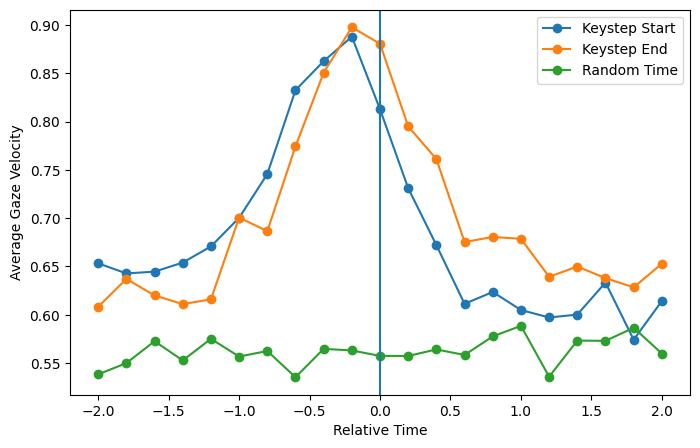

In [141]:
plt.figure(figsize=(8, 5))

plt.plot(start_avg["time_bin"], start_avg["gaze_vel"], marker="o", label = "Keystep Start")
plt.plot(end_avg["time_bin"], end_avg["gaze_vel"], marker="o", label = "Keystep End")
plt.plot(random_avg["time_bin"], random_avg["gaze_vel"], marker="o", label = "Random Time")


plt.axvline(0)

plt.xlabel("Relative Time")
plt.ylabel("Average Gaze Velocity")
plt.legend()
plt.show()

# Compare Pose and Gaze

In [142]:
pose_corr = pose_df[["take_uid", "time", "motion"]].copy()
pose_corr["time_bin"] = (pose_corr["time"]*5).round() / 5
gaze_corr = gaze_df[["take_uid", "time", "gaze_vel"]].copy()
gaze_corr["time_bin"] = (gaze_corr["time"]*5).round() / 5

In [143]:
pose_corr = pose_corr.groupby(["take_uid", "time_bin"])["motion"].mean().reset_index()
gaze_corr = gaze_corr.groupby(["take_uid", "time_bin"])["gaze_vel"].mean().reset_index()

In [144]:
pose_gaze = pose_corr.merge(gaze_corr, on=["take_uid", "time_bin"])
pose_gaze.head()

,take_uid,time_bin,motion,gaze_vel
0,062ed386-05a4-4ff5-a8ff-2235045349d7,0.2,0.021082,3.537621
1,062ed386-05a4-4ff5-a8ff-2235045349d7,0.4,0.027345,0.992755
2,062ed386-05a4-4ff5-a8ff-2235045349d7,0.6,0.029907,0.314176
3,062ed386-05a4-4ff5-a8ff-2235045349d7,0.8,0.044682,0.188208
4,062ed386-05a4-4ff5-a8ff-2235045349d7,1.0,0.015142,0.139343


In [145]:
pose_gaze[["motion", "gaze_vel"]].corr()

,motion,gaze_vel
motion,1.00000,0.20208
gaze_vel,0.20208,1.00000


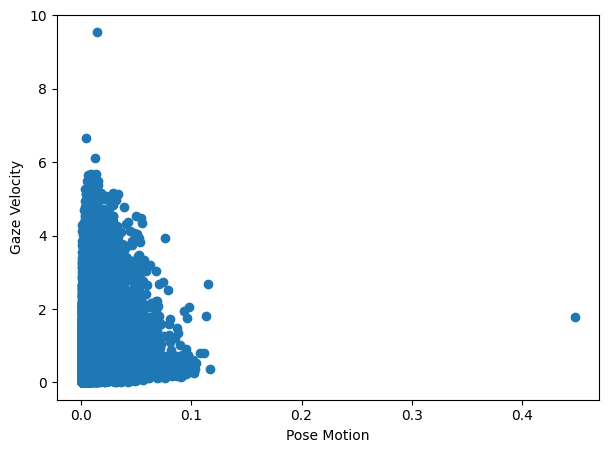

In [146]:
plt.figure(figsize=(7,5))
plt.scatter(pose_gaze["motion"], pose_gaze["gaze_vel"])
plt.xlabel("Pose Motion")
plt.ylabel("Gaze Velocity")
plt.show()

# Human Simulation

In [147]:
human_examples = all_examples[all_examples["num_exo_videos"]>0].sample(n=30, random_state=42).copy()
human_examples.to_csv("human_analysis_examples.csv", index=False)

In [178]:
human_df = pd.read_csv("/Users/diyadinesh/egoexo4d_analysis/human_analysis_examples_just_essentials.csv")
human_df.head()

,take_uid,take_name,scenario,segment_index,keystep_id,step_unique_id,keystep_name,keystep_description,start_min,end_min,...,ego_start,ego_end,exo_videos,exo_start_pred,exo_end_pred,exo_start,exo_end,start_min.1,end_min.1,keystep_description.1
0,cfe591d1-79ad-4784-8d2b-429eabddf944,utokyo_pcr_2001_28_2,Covid-19 Rapid Antigen Test,7,83,869,Dispose waste,put the funnel into the waste bag,1.00000:52.07000,1.00000:59.80000,...,1.59,2.03,/Users/diyadinesh/egoexo4d/takes/utokyo_pcr_20...,119,124,1.59,2.04,1.00000:52.07000,1.00000:59.80000,put the funnel into the waste bag
1,e52bd93e-021f-4208-aa02-ad1e64c03399,nus_cpr_14_1,First Aid - CPR,0,2,979,Have a conversation asking different questions,Have a conversation with people around asking ...,0.00000:14.36000,0.00000:18.07000,...,0.17,0.20,/Users/diyadinesh/egoexo4d/takes/nus_cpr_14_1/...,13,20,0.13,0.20,0.00000:14.36000,0.00000:18.07000,Have a conversation with people around asking ...
2,f1c3d2f5-e6bf-4899-a40d-12489d1ebb11,iiith_cooking_77_2,Cooking an Omelet,27,629,629,Get spatula,get a spatula from the counter top,1.00000:39.09000,1.000:45.620,...,1.45,1.47,/Users/diyadinesh/egoexo4d/takes/iiith_cooking...,104,105,1.44,1.45,1.00000:39.09000,1.000:45.620,get a spatula from the counter top
3,5dc6b68f-c360-4519-8b45-1d9ba21dbeed,nus_covidtest_22_2,Covid-19 Rapid Antigen Test,15,52,863,Position the covid 19 test tube on the box,Position test tube on the box.,1.00000:52.45000,1.00000:53.65000,...,1.51,1.54,/Users/diyadinesh/egoexo4d/takes/nus_covidtest...,112,115,1.52,1.55,1.00000:52.45000,1.00000:53.65000,Position test tube on the box.
4,d8a7872e-aa42-4296-a4b8-53b72f3c8b19,georgiatech_covid_05_8,Covid-19 Rapid Antigen Test,9,36,847,Dip the swab into the testing tube,Insert the soft end of the collection swab int...,0.00000:45.49000,0.0000:48.5200,...,0.47,0.54,/Users/diyadinesh/egoexo4d/takes/georgiatech_c...,46,49,0.46,0.49,0.00000:45.49000,0.0000:48.5200,Insert the soft end of the collection swab int...


In [179]:
ego_iou = []
exo_iou = []

for row in human_df.itertuples():
    intersection_start = max(row.start_sec, row.ego_start_pred)
    intersection_end = min(row.end_sec, row.ego_end_pred)
    intersection = max(0, intersection_end - intersection_start)

    union_start = min(row.start_sec, row.ego_start_pred)
    union_end = max(row.end_sec, row.ego_end_pred)

    union = union_end - union_start

    ego_iou += [intersection/union]

    intersection_start = max(row.start_sec, row.exo_start_pred)
    intersection_end = min(row.end_sec, row.exo_end_pred)
    intersection = max(0, intersection_end - intersection_start)

    union_start = min(row.start_sec, row.exo_start_pred)
    union_end = max(row.end_sec, row.exo_end_pred)

    union = union_end - union_start

    exo_iou += [intersection/union]
    
    
    

In [180]:
human_df["ego_iou"] = ego_iou
human_df["exo_iou"] = exo_iou
human_df[["start_sec", "end_sec", "ego_start_pred", "ego_end_pred", "exo_start_pred", "exo_end_pred", "ego_iou", "exo_iou"]].head()

,start_sec,end_sec,ego_start_pred,ego_end_pred,exo_start_pred,exo_end_pred,ego_iou,exo_iou
0,112.06603,119.79936,119,123,119,124,0.073108,0.066982
1,14.36236,18.06876,17,20,13,20,0.189576,0.529486
2,99.09226,105.61800,105,107,104,105,0.078151,0.153239
3,112.44579,113.65054,111,114,112,115,0.401583,0.401583
4,45.49492,48.52090,47,54,46,49,0.178823,0.719213


In [181]:
"Ego Mean tIoU", human_df["ego_iou"].mean()

('Ego Mean tIoU', 0.46132616213543887)

In [182]:
"Exo Mean tIoU", human_df["exo_iou"].mean()

('Exo Mean tIoU', 0.5899247930719508)

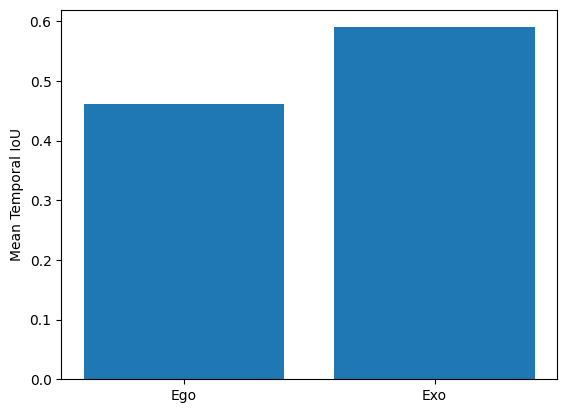

In [183]:
means = [human_df["ego_iou"].mean(), human_df["exo_iou"].mean()]
plt.bar(["Ego", "Exo"], means)
plt.ylabel("Mean Temporal IoU")
plt.show()

In [184]:
human_df["ego_start_error"] = abs(human_df["ego_start_pred"]-human_df["start_sec"])
print("Ego Start Error", human_df["ego_start_error"].mean())

human_df["ego_end_error"] = abs(human_df["ego_end_pred"]-human_df["end_sec"])
print("Ego End Error", human_df["ego_end_error"].mean())

human_df["exo_start_error"] = abs(human_df["exo_start_pred"]-human_df["start_sec"])
print("Exo Start Error", human_df["exo_start_error"].mean())

human_df["exo_end_error"] = abs(human_df["exo_end_pred"]-human_df["end_sec"])
print("Exo End Error", human_df["exo_end_error"].mean())


Ego Start Error 2.6438116666666684
Ego End Error 2.942247000000001
Exo Start Error 1.9757056666666684
Exo End Error 1.9086089999999998


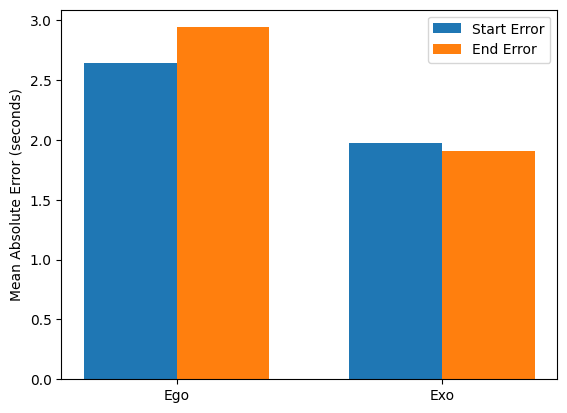

In [185]:
start_errors = [human_df["ego_start_error"].mean(), human_df["exo_start_error"].mean()]

end_errors = [human_df["ego_end_error"].mean(), human_df["exo_end_error"].mean()]

x = np.arange(2)

width = 0.35

plt.bar(x - width/2, start_errors, width, label="Start Error")

plt.bar(x + width/2, end_errors, width, label="End Error")

plt.xticks(x, ["Ego", "Exo"])

plt.ylabel("Mean Absolute Error (seconds)")

plt.legend()

plt.show()

In [186]:
human_df["better_view"] = np.where(human_df["ego_iou"] > human_df["exo_iou"], "Ego", np.where(human_df["exo_iou"] > human_df["ego_iou"], "Exo", "Tie"))

In [187]:
human_df["better_view"].value_counts()

better_view
Exo    15
Tie    10
Ego     5
Name: count, dtype: int64

In [188]:
human_df["better_view"].value_counts(normalize=True) * 100

better_view
Exo    50.000000
Tie    33.333333
Ego    16.666667
Name: proportion, dtype: float64

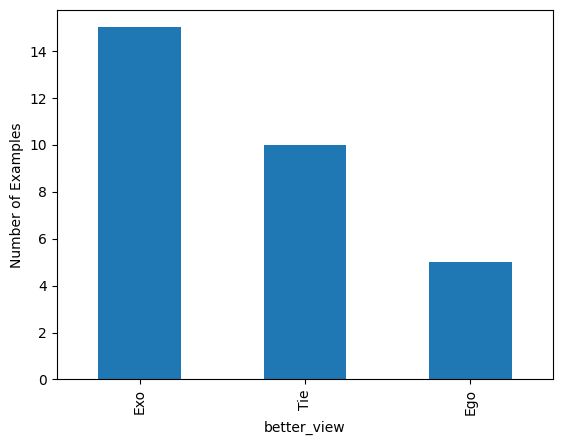

In [189]:
human_df["better_view"].value_counts().plot(kind="bar")

plt.ylabel("Number of Examples")

plt.show()

In [190]:
human_df["ego_exo_diff"] = human_df["ego_iou"]-human_df["exo_iou"]
print("Ego Favored")
human_df.sort_values("ego_exo_diff", ascending=False)[["keystep_name", "ego_iou", "exo_iou", "ego_exo_diff"]].head(10)

Ego Favored


,keystep_name,ego_iou,exo_iou,ego_exo_diff
15,Get fork,0.623418,0.361895,0.261523
8,Get cucumber,0.717722,0.486100,0.231622
9,Push the level inward and turn the axle CW to ...,0.259824,0.145108,0.114716
6,Arrange test material,0.890056,0.871513,0.018543
0,Dispose waste,0.073108,0.066982,0.006126
29,Shake the test tube,0.729336,0.729336,0.000000
18,carefully open the test tube seal paper,0.917985,0.917985,0.000000
7,Squeeze the brake,0.489703,0.489703,0.000000
3,Position the covid 19 test tube on the box,0.401583,0.401583,0.000000
10,Loosen both axle nuts using a wrench,0.679223,0.679223,0.000000


In [191]:
print("Exo Favored")
human_df.sort_values("ego_exo_diff")[["keystep_name", "ego_iou", "exo_iou", "ego_exo_diff"]].head(10)

Exo Favored


,keystep_name,ego_iou,exo_iou,ego_exo_diff
17,Dispose waste,0.176131,0.821944,-0.645813
4,Dip the swab into the testing tube,0.178823,0.719213,-0.540391
13,Get tea leaves,0.004315,0.483782,-0.479467
26,Get a bowl,0.277089,0.730699,-0.453610
22,Rotate and swirl the swab around for 5-10 times,0.563236,0.962951,-0.399716
11,Loosen both axle nuts using a wrench,0.257026,0.625297,-0.368271
1,Have a conversation asking different questions,0.189576,0.529486,-0.339910
25,Apply a few drops of the testing solution to t...,0.630593,0.917227,-0.286633
19,Unwrap testing plate,0.477611,0.716417,-0.238806
27,Roll the wheel,0.561030,0.755668,-0.194637


In [192]:
for threshold in [0.3, 0.5, 0.7]:
    ego_accuracy = (human_df["ego_iou"] >= threshold).mean()

    exo_accuracy = (human_df["exo_iou"] >= threshold).mean()

    print(threshold,"Ego:",ego_accuracy,"Exo:",exo_accuracy)

0.3 Ego: 0.6333333333333333 Exo: 0.8666666666666667
0.5 Ego: 0.4666666666666667 Exo: 0.6333333333333333
0.7 Ego: 0.2 Exo: 0.4
